# NZ Market Insights — Deep Analysis

Cross-dataset analysis exploring relationships between macroeconomic indicators (inflation, GDP growth, unemployment) and the housing market for New Zealand (2006-2025), plus investor-relevant snapshots (deposit vs. mortgage rate spread, house prices in foreign currencies) and regional/multi-variable extensions.

**Data sources**: `economic_indicators` (World Bank), `housing_sale_price` / `housing_affordability` (HUD / data.govt.nz Urban Development dataset), `bank_rates` / `loan_rates` (BNZ), `fx_rates` (Frankfurter API). See the project [ROADMAP.md](../ROADMAP.md) for how each is collected.

**A note on the affordability indices**: `mortgage_affordability_index`, `deposit_affordability_index`, and `rent_affordability_index` compare the growth of housing costs against the growth of median household income, indexed to a Q1 2012 baseline. **A higher value means worse affordability** (costs growing faster than income) — confirmed against the [official dataset description](https://catalogue.data.govt.nz/dataset/d9585bff-7f6a-49c5-8fb0-5a6ce23e32c7), not assumed from the raw numbers.

---

# NZ 市场洞察 — 深度分析

跨数据源分析，探索新西兰宏观经济指标(通胀率、GDP增长率、失业率)与房产市场(2006-2025)之间的关系，附带对投资者有参考价值的快照分析(定存vs房贷利差、房价折算外币)，以及区域对比、多元回归等进阶内容。

**数据来源**：`economic_indicators`(World Bank)、`housing_sale_price`/`housing_affordability`(HUD / data.govt.nz Urban Development 数据集)、`bank_rates`/`loan_rates`(BNZ)、`fx_rates`(Frankfurter API)。各数据源的抓取方式见项目 [ROADMAP.md](../ROADMAP.md)。

**关于可负担性指数的说明**：`mortgage_affordability_index`/`deposit_affordability_index`/`rent_affordability_index` 比较的是"住房成本涨幅"与"家庭可支配收入涨幅"，以 2012年第一季度 为基准。**数值越高代表可负担性越差**(成本涨得比收入快)——这一点已对照[官方数据集说明](https://catalogue.data.govt.nz/dataset/d9585bff-7f6a-49c5-8fb0-5a6ce23e32c7)核实过，不是凭数字趋势猜的。


## Setup

---

## 环境准备


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from db import get_engine

engine = get_engine()



## Data Preparation

### Step 1: Pivot economic indicators from long to wide format

`economic_indicators` stores one row per (year, indicator name). Correlation and regression need one column per indicator, so this pivots it using conditional aggregation (Postgres has no native `PIVOT`).

---

## 数据准备

### 第1步：把经济指标从长格式转成宽格式

`economic_indicators` 表现在是"一行一个指标一个年份"。要做相关性/回归分析，需要"一行一个年份，每个指标各自一列"，用 `CASE WHEN` + 聚合函数手动转换(Postgres 没有原生 `PIVOT` 语法)。


In [2]:
economic_wide = pd.read_sql("""
    SELECT
        year,
        MAX(CASE WHEN indicator_name = 'inflation_rate' THEN value END) AS inflation_rate,
        MAX(CASE WHEN indicator_name = 'gdp_growth_rate' THEN value END) AS gdp_growth_rate,
        MAX(CASE WHEN indicator_name = 'unemployment_rate' THEN value END) AS unemployment_rate
    FROM economic_indicators
    GROUP BY year
    ORDER BY year
""", engine)

economic_wide


,year,inflation_rate,gdp_growth_rate,unemployment_rate
0,2006,3.365402,2.774443,3.857
1,2007,2.376143,3.063122,3.661
2,2008,3.958949,-1.025611,4.167
3,2009,2.115651,-0.040260,6.121
4,2010,2.302024,1.471825,6.557
5,2011,4.027907,2.144500,6.491
6,2012,1.059913,2.302564,6.931
7,2013,1.134423,2.564836,5.839
8,2014,1.227508,3.819336,5.428
9,2015,0.292705,3.729683,5.415


### Step 2: Check housing_sale_price granularity

Before joining, check whether a ready-made national-level row already exists — this avoids hand-aggregating city-level rows, which would need careful weighting to avoid distortion from house-size mix shifts across years.

---

### 第2步：检查 housing_sale_price 的颗粒度

在 JOIN 之前，先看数据源本身有没有现成的"全国汇总"级别——这样能避免自己手动聚合城市级数据(手动聚合容易在"不同年份房屋规模结构变化"这件事上踩坑，需要仔细加权)。


In [3]:
area_types = pd.read_sql("SELECT DISTINCT area_type, COUNT(*) FROM housing_sale_price GROUP BY area_type", engine)
print(area_types)

national_housing = pd.read_sql("SELECT * FROM housing_sale_price WHERE area_type = 'NZ' ORDER BY year", engine)
national_housing


  area_type  count
0       EUA    272
1        NZ     34
2       Reg    569
3        TA   2269


,id,year,area_name,area_code,area_type,sum_floor_area_sold,sum_sale_price,number_sales,price_per_m2,number_bc,cost_per_m2,sum_value_new,pcr
0,17131,1993,New Zealand,0,NZ,7718457.0,6.540261e+09,50976,847.353378,13876.0,888.369667,2.124966e+09,0.953830
1,17132,1994,New Zealand,0,NZ,9382596.0,8.825542e+09,61580,940.629009,16230.0,923.673752,2.709005e+09,1.018356
2,17133,1995,New Zealand,0,NZ,8847019.0,9.071041e+09,58727,1025.321723,14541.0,953.518250,2.569109e+09,1.075304
3,17134,1996,New Zealand,0,NZ,9400882.0,1.055686e+10,62905,1122.964438,17142.0,992.933482,3.136302e+09,1.130956
4,17135,1997,New Zealand,0,NZ,9239725.0,1.085577e+10,61754,1174.901630,18594.0,1032.614058,3.408954e+09,1.137794
5,17136,1998,New Zealand,0,NZ,7308426.0,8.522650e+09,48120,1166.140236,15252.0,1067.661442,2.879958e+09,1.092238
6,17137,1999,New Zealand,0,NZ,8241266.0,9.883894e+09,53576,1199.317378,19193.0,1071.481884,3.753791e+09,1.119307
7,17138,2000,New Zealand,0,NZ,7268888.0,8.900892e+09,46423,1224.519052,15394.0,1085.232148,3.202188e+09,1.128348
8,17139,2001,New Zealand,0,NZ,8942723.0,1.121829e+10,56549,1254.460416,15805.0,1106.659674,3.455955e+09,1.133556
9,17140,2002,New Zealand,0,NZ,12555066.0,1.741824e+10,80595,1387.347245,19140.0,1155.458021,4.562888e+09,1.200690


`area_type = 'NZ'` is a ready-made national aggregate — one row per year, 1993-2026. 2026 is a partial year (only ~8,400 sales vs 50,000-80,000 in complete years) and is excluded from every analysis below.

---

`area_type = 'NZ'` 正好是数据源自带的全国汇总，一年一条记录，覆盖1993-2026年。2026年数据不完整(只有约8400笔成交，正常年份是5-8万笔)，后面所有分析都排除这一年。


### Step 3: SQL JOIN — combine economic indicators with national housing metrics

---

### 第3步：SQL JOIN — 把经济指标和全国房产指标关联起来


In [4]:
combined = pd.read_sql("""
    WITH economic_wide AS (
        SELECT
            year,
            MAX(CASE WHEN indicator_name = 'inflation_rate' THEN value END) AS inflation_rate,
            MAX(CASE WHEN indicator_name = 'gdp_growth_rate' THEN value END) AS gdp_growth_rate,
            MAX(CASE WHEN indicator_name = 'unemployment_rate' THEN value END) AS unemployment_rate
        FROM economic_indicators
        GROUP BY year
    )
    SELECT
        e.year,
        e.inflation_rate,
        e.gdp_growth_rate,
        e.unemployment_rate,
        h.sum_floor_area_sold,
        h.sum_sale_price,
        h.number_sales,
        h.price_per_m2,
        h.number_bc,
        h.cost_per_m2,
        h.sum_value_new,
        h.pcr
    FROM economic_wide e
    JOIN housing_sale_price h
        ON e.year = h.year
    WHERE h.area_type = 'NZ' AND h.year != 2026
    ORDER BY e.year
""", engine)

combined


,year,inflation_rate,gdp_growth_rate,unemployment_rate,sum_floor_area_sold,sum_sale_price,number_sales,price_per_m2,number_bc,cost_per_m2,sum_value_new,pcr
0,2006,3.365402,2.774443,3.857,14559233.0,3.486948e+10,95697,2395.007938,19996.0,1520.585001,6.549321e+09,1.575057
1,2007,2.376143,3.063122,3.661,13362481.0,3.546676e+10,87410,2654.204757,20282.0,1623.357312,7.048210e+09,1.635010
2,2008,3.958949,-1.025611,4.167,8068235.0,2.037033e+10,51311,2524.756231,14179.0,1746.047663,5.365061e+09,1.445984
3,2009,2.115651,-0.040260,6.121,9997506.0,2.561303e+10,63049,2561.941748,11574.0,1796.350370,4.512441e+09,1.426193
4,2010,2.302024,1.471825,6.557,8138039.0,2.157646e+10,51344,2651.309361,13066.0,1807.757047,5.101847e+09,1.466629
5,2011,4.027907,2.144500,6.491,9188259.0,2.454005e+10,57715,2670.804671,11112.0,1871.876920,4.399328e+09,1.426806
6,2012,1.059913,2.302564,6.931,11187282.0,3.145221e+10,70324,2811.425482,13733.0,1944.993889,5.752181e+09,1.445468
7,2013,1.134423,2.564836,5.839,11708550.0,3.551529e+10,73748,3033.278274,16721.0,2052.188028,7.340237e+09,1.478070
8,2014,1.227508,3.819336,5.428,11163735.0,3.629981e+10,69408,3251.582949,18359.0,2179.969637,8.527359e+09,1.491573
9,2015,0.292705,3.729683,5.415,13742625.0,4.882095e+10,86322,3552.520121,19038.0,2302.990372,9.146715e+09,1.542568


### Step 4: Add an intuitive "average price per house" figure

`price_per_m2` is the statistically sound metric for trend/correlation work (it controls for house-size mix). It is not, however, an intuitive number for a general audience — `avg_price_per_house` is added separately for that purpose and is *not* included in the correlation analysis below (it would just restate `price_per_m2` under a different denominator).

---

### 第4步：补一个更直观的"每栋平均价"

`price_per_m2`(每平米单价)是做趋势/相关性分析在统计上更站得住脚的指标(排除了房屋规模差异的干扰)，但对普通读者来说不够直观——额外算一个 `avg_price_per_house`(每栋平均成交价)专门用于直观展示，**不会**放进下面的相关性分析(放进去只是用另一个分母重复表达同一件事，没有新信息)。


In [5]:
combined['avg_price_per_house'] = combined['sum_sale_price'] / combined['number_sales']


### Step 5: Check housing_affordability granularity, then merge with pandas

`housing_affordability` also has a national `'NZ'` level, but at **quarterly** granularity, unlike the annual economic/sale-price data. This step aggregates it to annual (`groupby` + `mean`) and joins it in using **pandas `merge()`** instead of another SQL JOIN — a deliberate comparison of the two approaches for the same kind of operation.

---

### 第5步：检查 housing_affordability 的颗粒度，用 pandas 合并

`housing_affordability` 也有全国级别(`'NZ'`)，但是**季度**颗粒度，跟按年份的经济/房价数据不一样。这一步先按年聚合(`groupby`+`mean`)，再用 **pandas 的 `merge()`** 接进来(不是再写一次 SQL JOIN)——是故意选的，对比同一类"关联"操作用两种技术分别怎么做。


In [6]:
affordability_area_types = pd.read_sql("SELECT DISTINCT area_type, COUNT(*) FROM housing_affordability GROUP BY area_type", engine)
print(affordability_area_types)

affordability_nz = pd.read_sql("SELECT * FROM housing_affordability WHERE area_type = 'NZ' ORDER BY record_date", engine)
affordability_nz


  area_type  count
0        NZ     90
1       Reg   1440
2        TA   5940


,id,area_name,area_type,record_date,mortgage_affordability_index,deposit_affordability_index,rent_affordability_index
0,45587,New Zealand,NZ,2003-12-31,0.8687,1.0828,0.9462
1,45669,New Zealand,NZ,2004-03-31,0.8713,1.0561,0.9476
2,45751,New Zealand,NZ,2004-06-30,0.8516,1.0517,0.9601
3,45833,New Zealand,NZ,2004-09-30,0.8082,1.0444,0.9750
4,45915,New Zealand,NZ,2004-12-31,0.8058,1.0186,0.9778
...,...,...,...,...,...,...,...
85,51573,New Zealand,NZ,2025-03-31,0.7888,0.7495,1.0708
86,51624,New Zealand,NZ,2025-06-30,0.8414,0.7647,1.1020
87,51706,New Zealand,NZ,2025-09-30,0.8807,0.7742,1.1264
88,51788,New Zealand,NZ,2025-12-31,0.9352,0.7772,1.1177


In [7]:
affordability_nz['record_date'] = pd.to_datetime(affordability_nz['record_date'])
affordability_nz['year'] = affordability_nz['record_date'].dt.year

affordability_yearly = affordability_nz.groupby('year')[
    ['mortgage_affordability_index', 'deposit_affordability_index', 'rent_affordability_index']
].mean().reset_index()

combined = combined.merge(affordability_yearly, on='year', how='inner')
combined


,year,inflation_rate,gdp_growth_rate,unemployment_rate,sum_floor_area_sold,sum_sale_price,number_sales,price_per_m2,number_bc,cost_per_m2,sum_value_new,pcr,avg_price_per_house,mortgage_affordability_index,deposit_affordability_index,rent_affordability_index
0,2006,3.365402,2.774443,3.857,14559233.0,3.486948e+10,95697,2395.007938,19996.0,1520.585001,6.549321e+09,1.575057,364373.790187,0.668300,0.919400,1.005075
1,2007,2.376143,3.063122,3.661,13362481.0,3.546676e+10,87410,2654.204757,20282.0,1623.357312,7.048210e+09,1.635010,405751.751942,0.561400,0.861125,0.989225
2,2008,3.958949,-1.025611,4.167,8068235.0,2.037033e+10,51311,2524.756231,14179.0,1746.047663,5.365061e+09,1.445984,396997.263497,0.628650,0.943525,1.001025
3,2009,2.115651,-0.040260,6.121,9997506.0,2.561303e+10,63049,2561.941748,11574.0,1796.350370,4.512441e+09,1.426193,406240.035501,0.887850,0.985400,1.029625
4,2010,2.302024,1.471825,6.557,8138039.0,2.157646e+10,51344,2651.309361,13066.0,1807.757047,5.101847e+09,1.466629,420233.308287,0.824100,0.982000,1.022325
5,2011,4.027907,2.144500,6.491,9188259.0,2.454005e+10,57715,2670.804671,11112.0,1871.876920,4.399328e+09,1.426806,425193.538104,0.921800,1.003575,1.017175
6,2012,1.059913,2.302564,6.931,11187282.0,3.145221e+10,70324,2811.425482,13733.0,1944.993889,5.752181e+09,1.445468,447247.165751,1.026325,0.987075,1.012625
7,2013,1.134423,2.564836,5.839,11708550.0,3.551529e+10,73748,3033.278274,16721.0,2052.188028,7.340237e+09,1.478070,481576.318489,0.962250,0.934150,1.012100
8,2014,1.227508,3.819336,5.428,11163735.0,3.629981e+10,69408,3251.582949,18359.0,2179.969637,8.527359e+09,1.491573,522991.735407,0.852925,0.908025,1.012325
9,2015,0.292705,3.729683,5.415,13742625.0,4.882095e+10,86322,3552.520121,19038.0,2302.990372,9.146715e+09,1.542568,565567.894981,0.870075,0.837800,1.011375


## Analysis 1: Correlation Overview

A correlation matrix is a screening tool, not a conclusion — the goal is to find which pairs have a strong enough signal to be worth a dedicated regression, and to avoid wasting effort on pairs that show nothing.

---

## 分析1：相关系数矩阵总览

相关系数矩阵是一个"筛选工具"，不是结论本身——目的是找出哪几对关系信号够强、值得专门做回归分析，避免在没什么关系的组合上浪费精力。


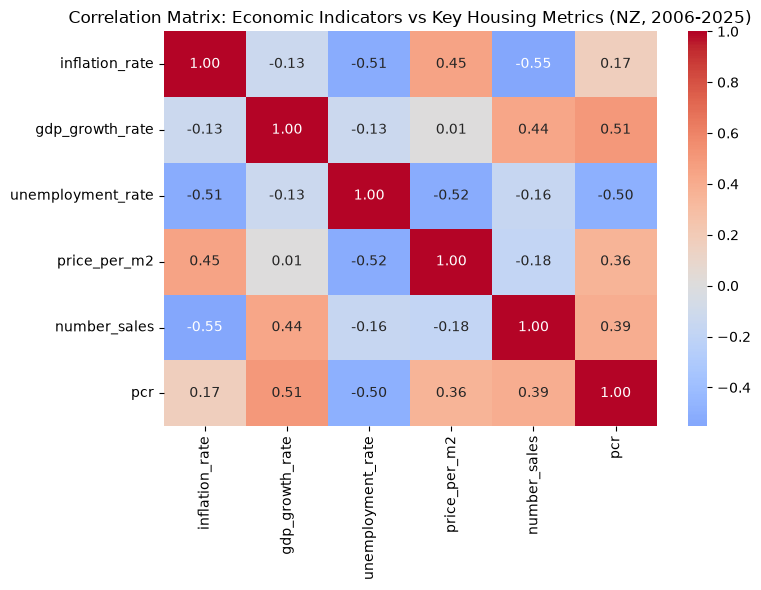

In [8]:
key_metrics = combined[['inflation_rate', 'gdp_growth_rate', 'unemployment_rate', 'price_per_m2', 'number_sales', 'pcr']]
corr_matrix = key_metrics.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Economic Indicators vs Key Housing Metrics (NZ, 2006-2025)')
plt.tight_layout()
plt.show()


Housing-side metrics were deliberately narrowed to three that represent genuinely different concepts (`price_per_m2` = price level, `number_sales` = market activity, `pcr` = price premium over construction cost) rather than including raw components like `sum_sale_price`/`cost_per_m2`, which are near-tautologically correlated with the metrics derived from them and would just add visual noise.

---

房产这边的指标特意精简成三个互相独立、各自代表不同概念的指标(`price_per_m2`=价格水平、`number_sales`=市场活跃度、`pcr`=相对建筑成本的溢价)，没有把 `sum_sale_price`/`cost_per_m2` 这类原始分量也塞进去——它们跟由它们计算出来的指标之间接近"定义上必然相关"，放进去只会增加视觉噪音，不增加信息量。


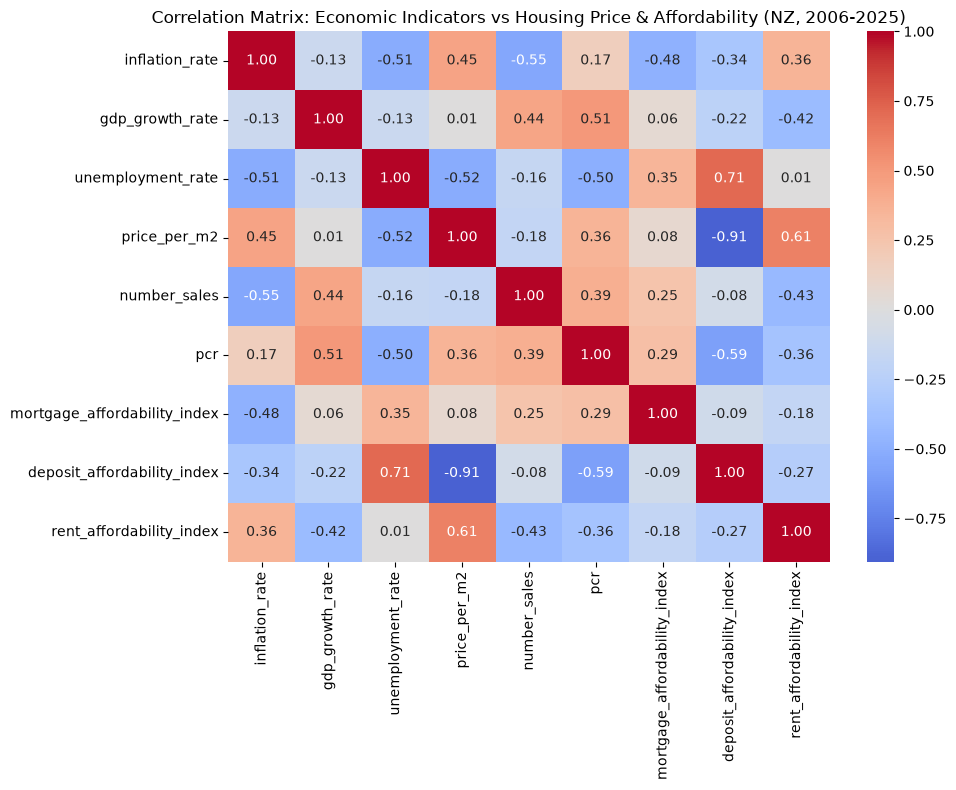

In [9]:
key_metrics2 = combined[[
    'inflation_rate', 'gdp_growth_rate', 'unemployment_rate',
    'price_per_m2', 'number_sales', 'pcr',
    'mortgage_affordability_index', 'deposit_affordability_index', 'rent_affordability_index'
]]
corr_matrix2 = key_metrics2.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix2, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Economic Indicators vs Housing Price & Affordability (NZ, 2006-2025)')
plt.tight_layout()
plt.show()


**Key signals from this matrix** (|r| > 0.5, cross-category only):

- `unemployment_rate` vs `deposit_affordability_index`: **0.71** — the strongest cross-relationship in the dataset. Higher unemployment associates with worse deposit affordability, a direct and intuitive income-shock story.
- `gdp_growth_rate` vs `pcr`: **0.51** — stronger economic growth associates with a higher price premium over construction cost.
- `unemployment_rate` vs `pcr`: **-0.50** — the same relationship in reverse.
- `price_per_m2` vs `deposit_affordability_index`: **-0.91** — very strong, but the affordability index measures *price growth relative to income growth*, not absolute price level, so this is not simply "higher prices, worse affordability" restated; the mechanism isn't fully clear from this data alone and is not asserted with confidence here.
- `gdp_growth_rate` vs `price_per_m2`: **0.01** — essentially no relationship. A genuine null result is reported as such rather than ignored.

The two strongest, most directly interpretable signals (`unemployment_rate` → `deposit_affordability_index` and `gdp_growth_rate` → `pcr`) are taken forward into dedicated regressions below.

---

**这张矩阵里的关键信号**(只看跨类别、|r|>0.5的)：

- `unemployment_rate` vs `deposit_affordability_index`：**0.71**——整张矩阵里最强的跨类别关系。失业率越高，存首付的可负担性越差，是最直接、最符合直觉的"收入冲击"故事。
- `gdp_growth_rate` vs `pcr`：**0.51**——经济增长越强，房价相对建筑成本的溢价越高。
- `unemployment_rate` vs `pcr`：**-0.50**——同一个关系反过来看。
- `price_per_m2` vs `deposit_affordability_index`：**-0.91**——非常强，但可负担性指数比的是"价格涨幅相对收入涨幅"，不是价格绝对水平，所以这不能简单理解成"房价越高、可负担性越差"——具体机制这份数据本身说不清楚，这里不做过度确定的解读。
- `gdp_growth_rate` vs `price_per_m2`：**0.01**——基本没关系。一个真实的"没发现"，如实报告，不回避。

最强、最容易解释的两个信号(`unemployment_rate`→`deposit_affordability_index` 和 `gdp_growth_rate`→`pcr`)会在下面做成专门的回归分析。


### A first look: all three affordability dimensions over time

Before jumping into regression, the most basic and readable view is simply plotting all three affordability indices together — which dimension is currently worst, and has that always been true?

---

### 先看一眼原始数据：三个可负担性维度放一起

在做回归分析之前，最基础、最直观的一张图其实是把三个可负担性指数直接画在一起——现在哪个维度最差，是不是一直都是这样？


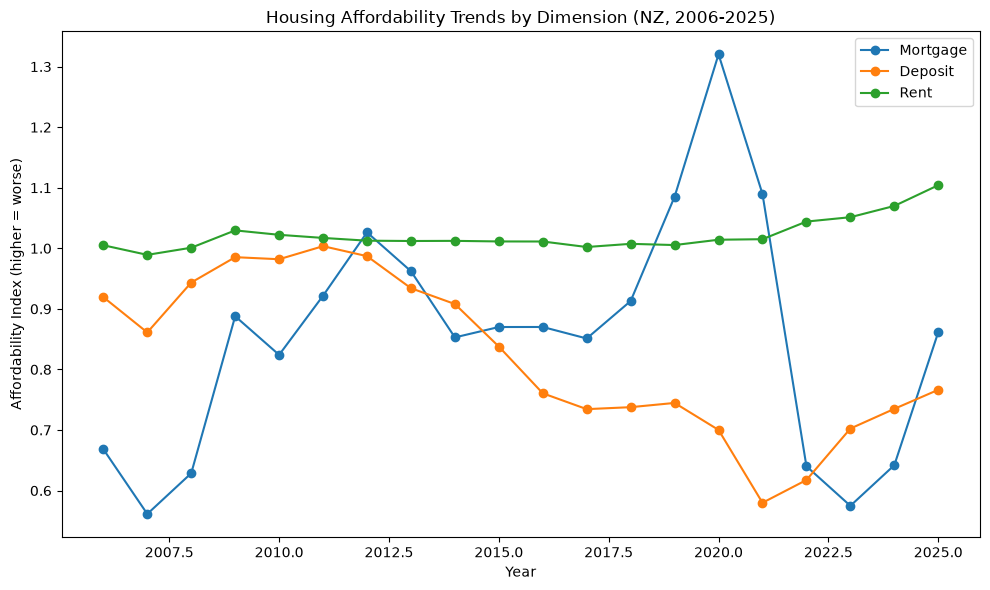

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(combined['year'], combined['mortgage_affordability_index'], marker='o', label='Mortgage')
plt.plot(combined['year'], combined['deposit_affordability_index'], marker='o', label='Deposit')
plt.plot(combined['year'], combined['rent_affordability_index'], marker='o', label='Rent')
plt.xlabel('Year')
plt.ylabel('Affordability Index (higher = worse)')
plt.title('Housing Affordability Trends by Dimension (NZ, 2006-2025)')
plt.legend()
plt.tight_layout()
plt.show()


## Analysis 2: Unemployment vs Housing Affordability

Regression on the strongest signal found above, then repeated for the other two affordability dimensions to check whether the relationship is general or specific to one aspect of affordability. A reusable function is used here since this is the same regression run three times (per this project's "rule of three" convention for when to abstract).

---

## 分析2：失业率 vs 住房可负担性

对上面发现的最强信号做正式回归，再对另外两个可负担性维度重复一遍，看这个关系是普遍存在还是只集中在某一个维度。这里用了一个可复用函数，因为同一套回归要跑三次(对应这个项目自己"三次重复法则"的约定——第三次重复就该抽象了)。


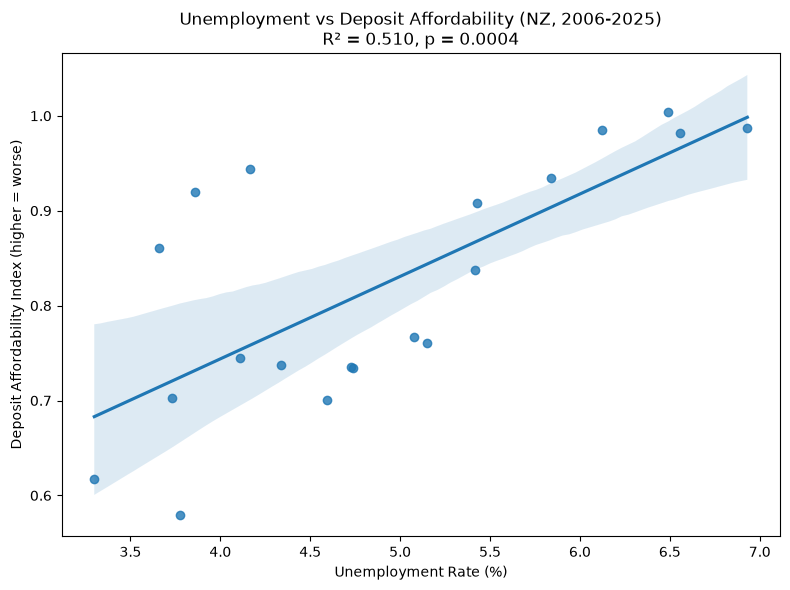

Regression equation: y = 0.0869 x + 0.3964
R-squared = 0.5100
p-value = 0.0004


(np.float64(0.086863475472334),
 np.float64(0.3964226565331108),
 np.float64(0.7141382958107422),
 np.float64(0.0004048855253768787))

In [11]:
from scipy import stats

def run_regression(x, y, x_label, y_label, title):
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    plt.figure(figsize=(8, 6))
    sns.regplot(x=x, y=y, ci=95)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(f'{title}\nR\u00b2 = {r_value**2:.3f}, p = {p_value:.4f}')
    plt.tight_layout()
    plt.show()

    print(f"Regression equation: y = {slope:.4f} x + {intercept:.4f}")
    print(f"R-squared = {r_value**2:.4f}")
    print(f"p-value = {p_value:.4f}")

    return slope, intercept, r_value, p_value

run_regression(
    combined['unemployment_rate'], combined['deposit_affordability_index'],
    'Unemployment Rate (%)', 'Deposit Affordability Index (higher = worse)',
    'Unemployment vs Deposit Affordability (NZ, 2006-2025)'
)


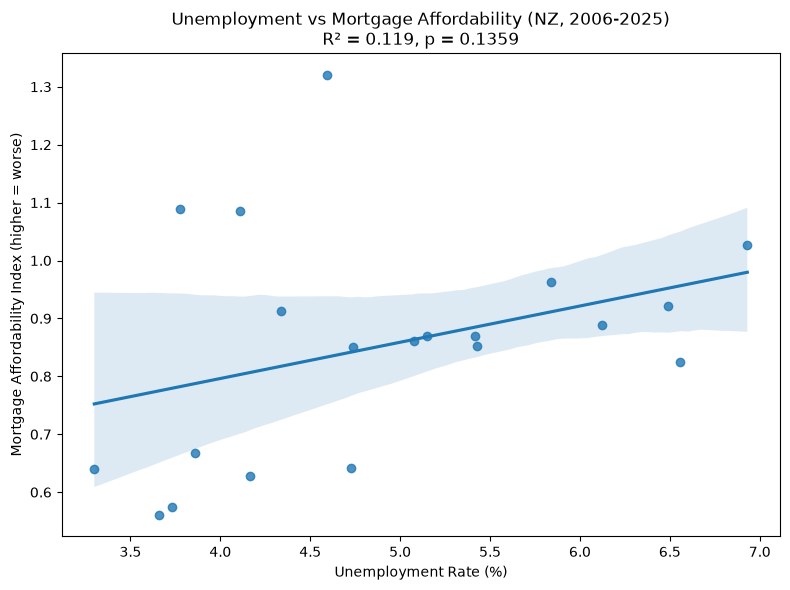

Regression equation: y = 0.0626 x + 0.5459
R-squared = 0.1192
p-value = 0.1359


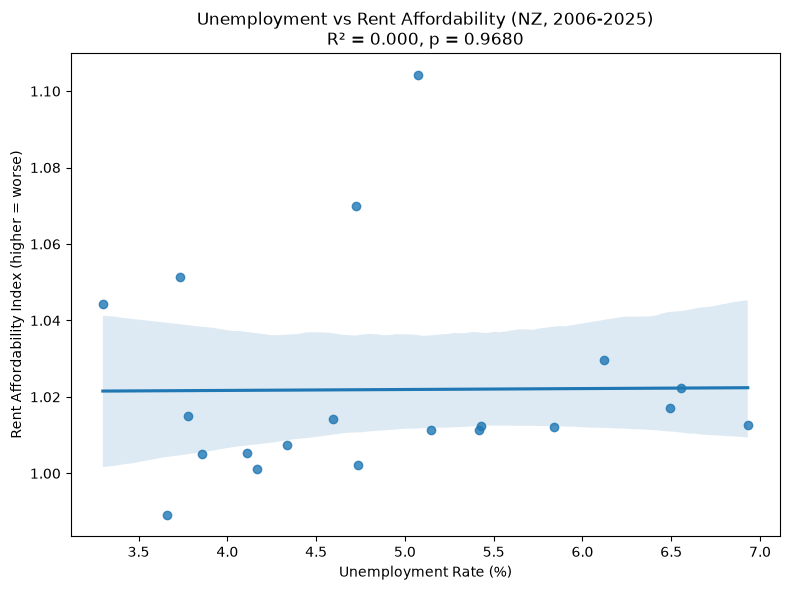

Regression equation: y = 0.0002 x + 1.0207
R-squared = 0.0001
p-value = 0.9680


(np.float64(0.0002409958049099417),
 np.float64(1.0207291446555216),
 np.float64(0.00959081909742195),
 np.float64(0.9679891861127391))

In [12]:
run_regression(
    combined['unemployment_rate'], combined['mortgage_affordability_index'],
    'Unemployment Rate (%)', 'Mortgage Affordability Index (higher = worse)',
    'Unemployment vs Mortgage Affordability (NZ, 2006-2025)'
)

run_regression(
    combined['unemployment_rate'], combined['rent_affordability_index'],
    'Unemployment Rate (%)', 'Rent Affordability Index (higher = worse)',
    'Unemployment vs Rent Affordability (NZ, 2006-2025)'
)


| Affordability dimension | R² | p-value | Significant? |
|---|---|---|---|
| Deposit | 0.510 | 0.0004 | Yes, strong |
| Mortgage | 0.119 | 0.1359 | No (p > 0.05) |
| Rent | 0.000 | 0.9680 | No signal |

Unemployment's effect on housing affordability is **not uniform** — it is concentrated almost entirely in the deposit dimension, with no statistically significant effect on mortgage servicing or rent burden. A plausible (unverified) explanation: deposit affordability depends on the ability to *accumulate savings*, which is directly and immediately disrupted by unemployment, whereas rent and mortgage rates are set through separate mechanisms (landlord pricing behaviour, central bank rate policy) that are less sensitive to a given year's unemployment rate. The finding here is "unemployment mainly raises the barrier to *entering* home ownership," not "unemployment worsens housing costs generally" — the more specific claim is the one the data actually supports.

**Caveat**: n=20 annual observations. Correlation/regression does not establish causation — both variables could share a common macro-cycle driver rather than one directly causing the other.

---

| 可负担性维度 | R² | p-value | 显著吗？ |
|---|---|---|---|
| 存首付 | 0.510 | 0.0004 | 是，强 |
| 房贷月供 | 0.119 | 0.1359 | 否 (p > 0.05) |
| 租金 | 0.000 | 0.9680 | 没信号 |

失业率对住房可负担性的影响**不是均匀分布的**——几乎全部集中在"存首付"这一个维度，对房贷月供负担、租金负担在统计上都不显著。一个合理(但未证实)的解释：存首付靠的是**积累储蓄**，失业会直接、立刻打断这个过程；而租金和房贷利率是通过别的机制(房东定价行为、央行利率政策)决定的，对某一年的失业率波动没那么敏感。这里得出的结论是"失业率主要抬高了'跨过购房门槛'这一步的难度"，而不是笼统的"失业率恶化住房成本"——更具体的说法才是数据真正支持的结论。

**局限性说明**：只有20个年度观测值。相关/回归不等于因果——两个变量也可能是被同一个宏观周期共同驱动，不一定是谁直接导致谁。


## Analysis 3: GDP Growth vs Price-Cost Ratio

The second-strongest signal from the correlation matrix, and a genuinely different story from Analysis 2: instead of a *demand-side income shock* (unemployment), this looks at whether general economic growth is associated with house prices decoupling further from construction cost — i.e. a rising land-value/speculative premium during growth periods.

---

## 分析3：GDP增长率 vs 房价-成本比(PCR)

相关系数矩阵里第二强的信号，也是跟分析2完全不同的一个故事：这次看的不是"需求端的收入冲击"(失业率)，而是整体经济增长是否会让房价相对建筑成本进一步脱钩——也就是经济增长期，地价/投机溢价是否会跟着上升。


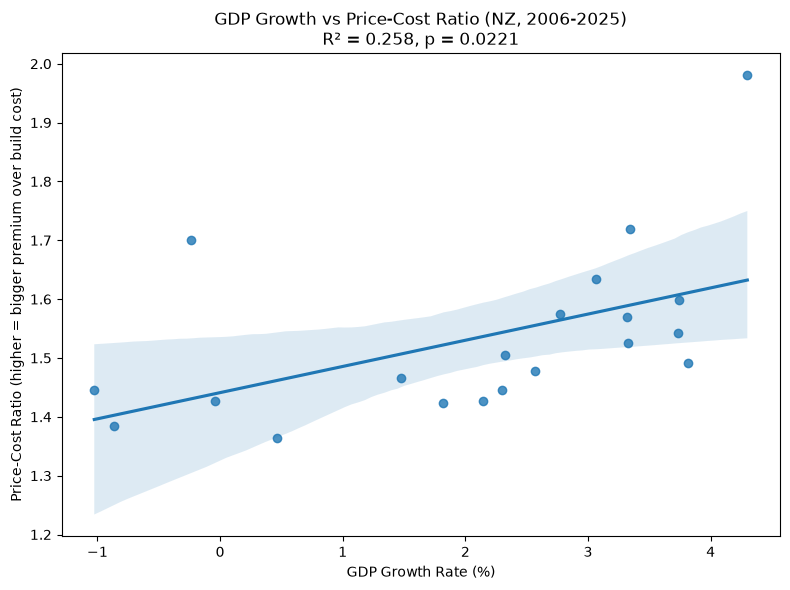

Regression equation: y = 0.0445 x + 1.4411
R-squared = 0.2585
p-value = 0.0221


(np.float64(0.044497442243446324),
 np.float64(1.4410956762477718),
 np.float64(0.5084133715075471),
 np.float64(0.022081203283640143))

In [13]:
run_regression(
    combined['gdp_growth_rate'], combined['pcr'],
    'GDP Growth Rate (%)', 'Price-Cost Ratio (higher = bigger premium over build cost)',
    'GDP Growth vs Price-Cost Ratio (NZ, 2006-2025)'
)


**Interpretation**: R² = 0.259, p = 0.022 — statistically significant (p < 0.05), but a moderate relationship, weaker than the unemployment-to-deposit-affordability link in Analysis 2. GDP growth explains roughly a quarter of the year-to-year variation in the price-cost ratio; the rest is driven by other factors (land supply constraints, interest rates, migration, etc. not modelled here). Directionally, stronger economic growth years do coincide with houses selling for more relative to what they cost to build — consistent with the PCR's stated purpose as a land-market-responsiveness indicator (Ministry of Housing and Urban Development), rather than construction costs themselves driving price changes.

---

**解读**：R² = 0.259，p = 0.022——统计上显著(p<0.05)，但关系强度中等，比分析2里"失业率→存首付可负担性"那组弱。GDP增长率大概能解释掉PCR年度波动的四分之一，剩下的由别的没纳入模型的因素决定(土地供给限制、利率、移民等)。方向上看，经济增长更强的年份，房价相对建筑成本确实卖得更贵——跟 PCR 官方定位("土地市场响应性指标"，Ministry of Housing and Urban Development)是一致的，不是建筑成本本身在驱动价格变化。


## Analysis 4: Multi-Variable Regression — Do the Economic Indicators Jointly Predict PCR?

Analyses 2 and 3 each tested one predictor at a time. But `inflation_rate`, `gdp_growth_rate`, and `unemployment_rate` are themselves correlated with each other (see the first correlation matrix), so a single-variable result can be confounded — a variable might look significant on its own only because it's a proxy for another one. A multi-variable OLS regression tests all three together, and reports which ones remain significant *after controlling for the other two*.

---

## 分析4：多元回归 — 三个经济指标一起，能不能联合预测 PCR？

分析2、3都是"一次只测一个自变量"。但 `inflation_rate`、`gdp_growth_rate`、`unemployment_rate` 这三个指标彼此之间本身就有相关性(参见第一张相关系数矩阵)，单变量结果可能被"混淆"——某个变量看起来显著，可能只是因为它是另一个变量的替身。多元 OLS 回归把三个一起放进模型，能看出**控制住另外两个变量之后**，哪些依然显著。


In [14]:
import statsmodels.api as sm

X = combined[['unemployment_rate', 'gdp_growth_rate', 'inflation_rate']]
X = sm.add_constant(X)
y = combined['pcr']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    pcr   R-squared:                       0.446
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     4.300
Date:                Fri, 07 Aug 2026   Prob (F-statistic):             0.0210
Time:                        13:58:32   Log-Likelihood:                 16.859
No. Observations:                  20   AIC:                            -25.72
Df Residuals:                      16   BIC:                            -21.74
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.7330      0.19

**Interpretation**: The joint model explains more variance overall (R²=0.446) than any single-variable regression above, but the three predictors are not equally responsible for that:

| Predictor | Coefficient | p-value | Significant (controlling for the other two)? |
|---|---|---|---|
| `gdp_growth_rate` | +0.040 | **0.032** | Yes |
| `unemployment_rate` | -0.058 | 0.070 | Marginal (just above 0.05) |
| `inflation_rate` | +0.001 | 0.967 | No — essentially zero effect |

`gdp_growth_rate` is the most robust predictor of `pcr` — it stays significant even after controlling for the other two economic indicators, unlike Analysis 3's single-variable version, this isolates GDP's effect *net of* what it shares with unemployment and inflation. `unemployment_rate`'s apparent single-variable relationship with `pcr` (r=-0.50 in the correlation matrix) largely **washes out** once GDP is controlled for — the two indicators were likely picking up much of the same signal. `inflation_rate` shows no meaningful relationship with `pcr` at all once the other two are in the model.

**Caveat**: with only 20 observations and 3 predictors, this model has limited statistical power, and the residual normality tests (Omnibus/Jarque-Bera, both p<0.01) suggest the residuals are not well-behaved — the reported p-values should be read as indicative, not definitive.

---

**解读**：联合模型整体解释力(R²=0.446)比上面任何一个单变量回归都高，但三个预测变量的贡献并不均等：

| 预测变量 | 系数 | p-value | 控制住另外两个后还显著吗？ |
|---|---|---|---|
| `gdp_growth_rate` | +0.040 | **0.032** | 是 |
| `unemployment_rate` | -0.058 | 0.070 | 勉强(刚超过0.05) |
| `inflation_rate` | +0.001 | 0.967 | 否——基本没影响 |

`gdp_growth_rate` 是对 `pcr` 最稳健的预测变量——即使控制住另外两个经济指标依然显著，这跟分析3的单变量版本不同，这里分离出的是 GDP **扣除掉跟失业率/通胀共享的部分之后**的独立效应。`unemployment_rate` 在相关系数矩阵里跟 `pcr` 看起来有(r=-0.50)的关系，一旦控制住 GDP 后**基本消失**——这两个指标很可能在单变量分析里捕捉到的是同一份信号的大部分。`inflation_rate` 在模型里跟 `pcr` 完全没有有意义的关系。

**局限性**：只有20个观测值配3个预测变量，模型的统计功效有限；残差正态性检验(Omnibus/Jarque-Bera，两者 p<0.01)显示残差不太符合正态分布假设——这里报告的 p-value 应该当作参考性的，不是definitive的确定结论。


## Analysis 5: Building Consents as a Leading Indicator

`number_bc` (building consents issued) represents future housing supply that hasn't been built yet — in theory, a genuine "leading indicator." This tests whether this year's consent volume correlates more strongly with *next year's* price-cost ratio than with the *same year's*, which would support treating it as a forward-looking signal rather than a coincident one.

---

## 分析5：建筑许可数量作为领先指标

`number_bc`(已批建筑许可数量)代表的是"还没建成"的未来供给——理论上是一个真正的"领先指标"(leading indicator)。这里检验:今年的建筑许可数量，跟"明年"的房价-成本比之间的相关性，是不是比跟"今年"的更强——如果是，说明它确实有"预示未来"的信号价值，而不只是跟当期同步波动。


In [15]:
combined_lag = combined.copy()
combined_lag['pcr_next_year'] = combined_lag['pcr'].shift(-1)

same_year_corr = combined_lag['number_bc'].corr(combined_lag['pcr'])
lead_corr = combined_lag['number_bc'].corr(combined_lag['pcr_next_year'])

print(f"Same-year correlation (number_bc vs pcr): {same_year_corr:.3f}")
print(f"Leading correlation (number_bc vs next year's pcr): {lead_corr:.3f}")


Same-year correlation (number_bc vs pcr): 0.784
Leading correlation (number_bc vs next year's pcr): 0.616


**Interpretation**: The same-year correlation (0.784) is actually *stronger* than the leading correlation (0.616) — this does **not** support the "building consents lead future prices" hypothesis as expected. If anything, the pattern looks more consistent with `number_bc` moving *with* current market conditions rather than predicting future ones — plausibly, developers apply for more consents when the *current* price-cost ratio is already attractive, rather than consents driving next year's prices. This is a genuine, somewhat counter-intuitive finding worth reporting as-is rather than forcing it to fit the "leading indicator" framing it was tested under.

---

**解读**：同期相关性(0.784)实际上比领先相关性(0.616)**更强**——这**不支持**"建筑许可能预示未来房价"这个预期假设。如果说有什么规律的话，`number_bc` 看起来更像是跟**当期**市场状况同步变化，而不是预测未来——一个合理的猜测是，开发商是在**当前**的房价-成本比已经有吸引力时才更多申请许可，而不是许可数量在带动明年的价格。这是一个真实的、有点反直觉的发现，如实报告，不强行往"领先指标"这个预设框架上套。


## Analysis 6: Real vs Nominal House Prices (Inflation-Adjusted)

Does property actually beat inflation, or does the nominal price chart just look impressive because of general inflation? Year-over-year `inflation_rate` values are compounded into a cumulative price index (`cumprod`), then used to deflate `price_per_m2` into constant (2006) dollars.

---

## 分析6：真实房价 vs 名义房价(通胀调整)

房产是不是真的跑赢了通胀，还是名义房价图看起来涨得猛只是因为整体物价也在涨？把逐年的 `inflation_rate` 用 `cumprod` 累积成一个物价指数，再用它把 `price_per_m2` 折算成"2006年币值"的真实价格。


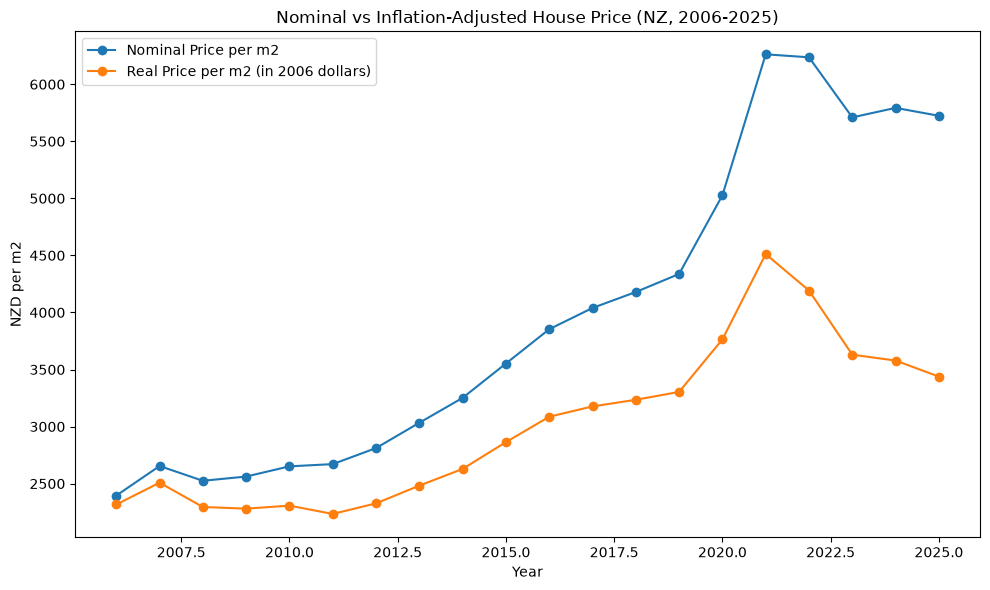

In [16]:
combined = combined.sort_values('year').reset_index(drop=True)

combined['cpi_index'] = (1 + combined['inflation_rate'] / 100).cumprod() * 100
combined['real_price_per_m2'] = combined['price_per_m2'] / (combined['cpi_index'] / 100)

plt.figure(figsize=(10, 6))
plt.plot(combined['year'], combined['price_per_m2'], marker='o', label='Nominal Price per m2')
plt.plot(combined['year'], combined['real_price_per_m2'], marker='o', label=f'Real Price per m2 (in {combined["year"].iloc[0]} dollars)')
plt.xlabel('Year')
plt.ylabel('NZD per m2')
plt.title('Nominal vs Inflation-Adjusted House Price (NZ, 2006-2025)')
plt.legend()
plt.tight_layout()
plt.show()


Real (inflation-adjusted) price per m² rose roughly **48%** from 2006 to 2025 — property genuinely outpaced general inflation over this period, not just nominally. The shape is worth noting beyond the headline number: a steady climb through 2006-2019, a sharp anomalous spike in 2020-2021 (the COVID-era low-rate/stimulus-driven property boom), a marked correction in 2022-2023 as interest rates rose to fight inflation, then a plateau through 2025.

---

剔除通胀后，每平米真实房价从2006到2025大概涨了**48%**——房产确实明显跑赢了通胀，不是名义数字造成的假象。除了这个总数，图形状本身也值得关注：2006-2019年是平稳爬升；2020-2021年出现明显异常尖峰(疫情期间低利率+刺激政策推动的房产热)；2022-2023年因为央行加息对抗通胀而明显回调；之后到2025年趋于平稳。


## Analysis 7: Deposit vs Mortgage Rate Spread

A current-snapshot (not trend) analysis — answers a concrete personal-finance question: is it better to hold savings in a term deposit, or pay down a mortgage early? Comparing `bank_rates` (term deposits) against `loan_rates` (home loans) at matching terms answers this directly, and doesn't require the rate history that Analyses 9-11 (deferred) would need.

Term strings differ in formatting between the two sources (`"18 month"` vs `"18 months"`), so both are converted to a common `days` unit before matching — a naive string match would silently drop most rows. The first version of this query also surfaced a real data-quality issue: a plain `ORDER BY fetched_at DESC LIMIT 20` pulled in duplicate historical snapshots from repeated cron runs; `DISTINCT ON (bank, term)` (Postgres-specific "latest row per group" syntax) fixed it.

---

## 分析7：定存 vs 房贷利率利差

这是一个当前快照(不是趋势)分析——回答一个具体的理财决策问题：把钱存定期划算，还是提前还房贷划算？把 `bank_rates`(定存)和 `loan_rates`(房贷)按相同期限对比，直接回答这个问题，也不需要分析9-11(已搁置)那种利率历史数据。

两边表期限字符串格式不一致(`"18 month"` vs `"18 months"`)，先统一换算成 `days` 天数再匹配——直接按字符串比对会悄悄漏掉大部分数据。这次查询第一版还顺带发现了一个真实的数据质量问题：单纯 `ORDER BY fetched_at DESC LIMIT 20` 会把 cron 反复运行产生的历史重复快照也拉进来；用 `DISTINCT ON (bank, term)`(Postgres 专属的"每组只取最新一条"语法)修复了这个问题。


In [17]:
current_bank_rates = pd.read_sql("""
    SELECT DISTINCT ON (bank, term) bank, term, rate
    FROM bank_rates
    ORDER BY bank, term, fetched_at DESC
""", engine)

current_loan_rates = pd.read_sql("""
    SELECT DISTINCT ON (bank, product, term) bank, product, term, rate
    FROM loan_rates
    ORDER BY bank, product, term, fetched_at DESC
""", engine)

def term_to_days(term):
    term = term.strip().lower()
    if term == 'variable':
        return None
    num_str, unit = term.split(' ')
    num = float(num_str)
    if unit.startswith('day'):
        return num
    if unit.startswith('month'):
        return num * 30
    if unit.startswith('year'):
        return num * 365
    return None

current_bank_rates['days'] = current_bank_rates['term'].apply(term_to_days)
current_loan_rates['days'] = current_loan_rates['term'].apply(term_to_days)

spread = current_bank_rates[['term', 'days', 'rate']].rename(columns={'rate': 'deposit_rate', 'term': 'deposit_term'}).merge(
    current_loan_rates[current_loan_rates['product'] == 'Standard'][['term', 'days', 'rate']].rename(columns={'rate': 'loan_rate', 'term': 'loan_term'}),
    on='days', how='inner'
)
spread['spread'] = spread['loan_rate'] - spread['deposit_rate']
spread.sort_values('days')


,deposit_term,days,deposit_rate,loan_term,loan_rate,spread
0,180 day,180.0,3.45,6 months,4.69,1.24
2,1 year,365.0,3.90,1 year,4.79,0.89
1,18 month,540.0,4.00,18 months,5.09,1.09
3,2 year,730.0,4.20,2 years,5.29,1.09
4,3 year,1095.0,4.40,3 years,5.29,0.89
5,4 year,1460.0,4.60,4 years,5.39,0.79
6,5 year,1825.0,4.70,5 years,5.49,0.79


The spread (mortgage rate minus deposit rate) is positive and roughly 0.8-1.2 percentage points across every term — the mortgage rate is always higher. In pure interest-rate terms, paying down debt saves more than a term deposit earns, at every matching term currently on offer.

---

利差(房贷利率减定存利率)在每个期限上都是正的，大约0.8-1.2个百分点——房贷利率始终更高。纯利率角度看，在现有每个可比期限上，提前还贷省下的利息都比存定期赚的利息多。


## Analysis 8: Regional Comparison

Everything above uses the national (`area_type = 'NZ'`) aggregate. A real property analyst would also look at regional variation — which major city is currently most expensive, and which has the worst deposit affordability? Both `housing_sale_price` and `housing_affordability` have matching city-level (`'TA'`) rows for the same six major cities already used in the frontend charts (`Auckland`, `Wellington City`, `Christchurch City`, `Hamilton City`, `Dunedin City`, `Tauranga City`), verified to use identical naming across both tables before joining.

---

## 分析8：区域对比

前面所有分析用的都是全国(`area_type = 'NZ'`)汇总数据。真正的房产分析师还会看区域差异——现在哪个主要城市房价最高，哪个城市"存首付"最难？`housing_sale_price` 和 `housing_affordability` 两张表都有跟前端图表用的同一组六个主要城市(`Auckland`、`Wellington City`、`Christchurch City`、`Hamilton City`、`Dunedin City`、`Tauranga City`)对应的城市级(`'TA'`)数据，两边命名已核实完全一致才拿来关联。


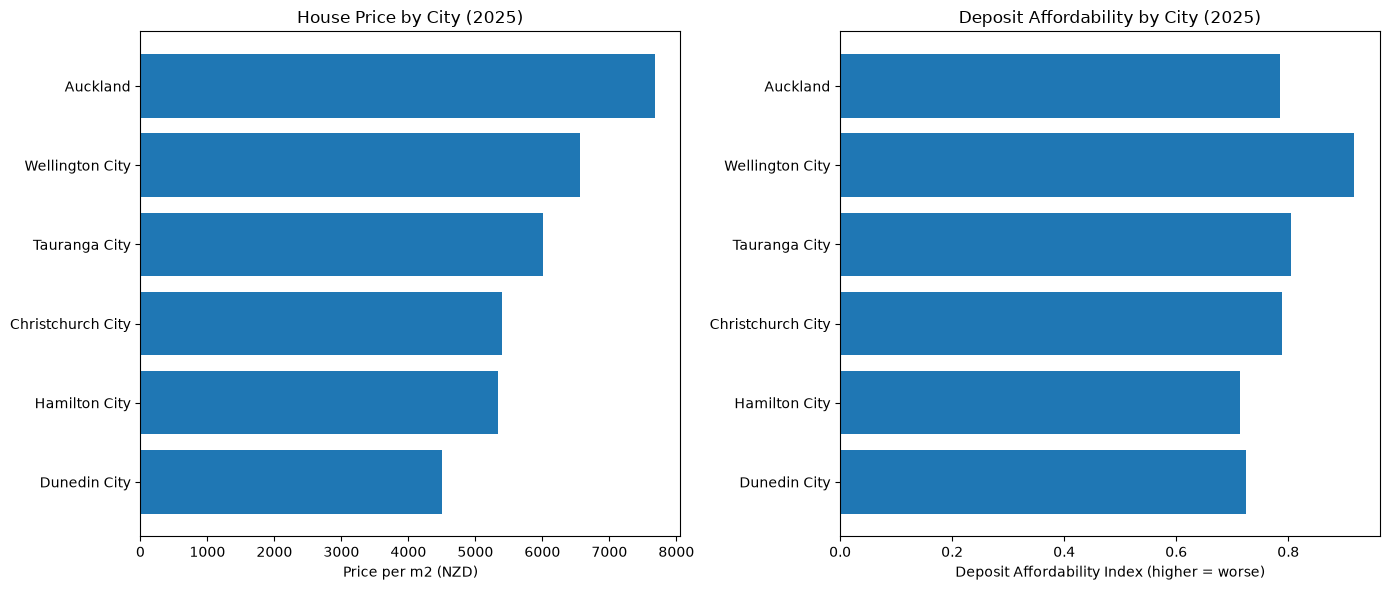

,area_name,price_per_m2,pcr,number_sales,mortgage_affordability_index,deposit_affordability_index,rent_affordability_index
0,Auckland,7675.100913,1.819320,15872,0.882325,0.784600,1.184275
5,Wellington City,6566.304926,1.230231,1661,1.031875,0.917850,1.240025
4,Tauranga City,6004.487704,1.226616,2478,0.904650,0.805150,0.998875
1,Christchurch City,5403.112507,1.351178,6592,0.886925,0.789450,1.032500
3,Hamilton City,5343.372612,1.386216,2385,0.803175,0.714350,1.017350
2,Dunedin City,4496.697621,1.012352,2119,0.815175,0.725375,1.082550


In [18]:
major_cities = ['Auckland', 'Wellington City', 'Christchurch City', 'Hamilton City', 'Dunedin City', 'Tauranga City']
latest_complete_year = int(combined['year'].max())

regional_price = pd.read_sql("""
    SELECT area_name, price_per_m2, pcr, number_sales
    FROM housing_sale_price
    WHERE area_type = 'TA' AND area_name = ANY(%(cities)s) AND year = %(year)s
""", engine, params={'cities': major_cities, 'year': latest_complete_year})

regional_affordability = pd.read_sql("""
    SELECT area_name,
           AVG(mortgage_affordability_index) AS mortgage_affordability_index,
           AVG(deposit_affordability_index) AS deposit_affordability_index,
           AVG(rent_affordability_index) AS rent_affordability_index
    FROM housing_affordability
    WHERE area_type = 'TA' AND area_name = ANY(%(cities)s) AND EXTRACT(YEAR FROM record_date) = %(year)s
    GROUP BY area_name
""", engine, params={'cities': major_cities, 'year': latest_complete_year})

regional = regional_price.merge(regional_affordability, on='area_name').sort_values('price_per_m2', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(regional['area_name'], regional['price_per_m2'])
axes[0].set_xlabel('Price per m2 (NZD)')
axes[0].set_title(f'House Price by City ({latest_complete_year})')
axes[0].invert_yaxis()

axes[1].barh(regional['area_name'], regional['deposit_affordability_index'])
axes[1].set_xlabel('Deposit Affordability Index (higher = worse)')
axes[1].set_title(f'Deposit Affordability by City ({latest_complete_year})')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

regional


**Interpretation**: Auckland is clearly the most expensive city by price level ($7,675/m²) and also has by far the highest price-cost premium (PCR=1.82) — consistent with it being NZ's largest, most land-constrained market. Dunedin is the cheapest ($4,497/m²) with a PCR close to 1.0, meaning houses there sell close to what they cost to build — very little speculative/land-scarcity premium.

The more interesting finding is in affordability, not price: **Wellington has the worst deposit affordability index (0.918) despite having a lower price level than Auckland** ($6,566/m² vs Auckland's $7,675/m²). Price level and affordability burden don't rank the same way — Wellington's house price growth has likely outpaced local income growth more than Auckland's has, even though Auckland remains more expensive in absolute terms. This is exactly the kind of distinction a simple "which city is priciest" ranking would miss.

**Caveat**: Wellington's `number_sales` (1,661) is roughly 10x smaller than Auckland's (15,872) — a much thinner market, so its price/affordability figures for a single year carry more year-to-year noise and should be read with that in mind.

---

**解读**：奥克兰在价格水平上明显最贵($7,675/m²)，价格-成本溢价(PCR=1.82)也远高于其他城市——符合它是新西兰最大、土地约束最紧的市场这个认知。达尼丁最便宜($4,497/m²)，PCR 接近1.0，说明那里房子的成交价接近建筑成本本身——投机/土地稀缺溢价很小。

更有意思的发现在"可负担性"这边，不在价格本身：**惠灵顿的存首付可负担性指数是六个城市里最差的(0.918)，尽管它的价格水平比奥克兰低**(惠灵顿 $6,566/m² vs 奥克兰 $7,675/m²)。价格水平排名和负担压力排名并不一致——惠灵顿的房价涨幅相对当地收入涨幅的差距，很可能比奥克兰更大，即使奥克兰绝对价格依然更贵。这正是单纯"哪个城市最贵"这种排名会漏掉的细节。

**局限性**：惠灵顿的 `number_sales`(1,661)大约只有奥克兰(15,872)的十分之一——市场规模小得多，单一年份的价格/可负担性数字年度波动噪音更大，解读时要考虑这一点。


## Analysis 9: House Price in Foreign Currencies

For a foreign investor, NZD price alone doesn't answer "how much would this actually cost me" — that depends on the current exchange rate to their home currency. This converts the latest national average house price into each tracked currency using the latest FX snapshot.

---

## 分析9：房价折算主要外币

对外国投资者来说，纽币价格本身回答不了"这到底要花我多少钱"——这取决于当前对他们本国货币的汇率。用最新的汇率快照，把最新一年的全国平均房价折算成每种主要货币。


In [19]:
current_fx_rates = pd.read_sql("""
    SELECT DISTINCT ON (base_currency, target_currency) base_currency, target_currency, rate
    FROM fx_rates
    ORDER BY base_currency, target_currency, fetched_at DESC
""", engine)

latest_nzd_price = combined.loc[combined['year'] == combined['year'].max(), 'avg_price_per_house'].values[0]

current_fx_rates['house_price_in_foreign_currency'] = latest_nzd_price * current_fx_rates['rate']
current_fx_rates[['target_currency', 'rate', 'house_price_in_foreign_currency']].sort_values('target_currency')


,target_currency,rate,house_price_in_foreign_currency
0,AUD,0.83676,7.491255e+05
1,CNY,3.94590,3.532643e+06
2,EUR,0.50901,4.557010e+05
3,GBP,0.43630,3.906060e+05
4,JPY,95.18000,8.521173e+07
5,SGD,0.75206,6.732962e+05
6,USD,0.58414,5.229626e+05


This is a currency-conversion snapshot, not a trend — it answers "what would this cost a foreign buyer today," not "is now a good time to convert." A genuine trend view (is NZD getting cheaper or more expensive for a given currency over time) is one of the deferred items below, since `fx_rates` only has a few days of history so far.

---

这是一次货币换算快照，不是趋势——回答的是"今天买要花多少钱"，不是"现在换汇划不划算"。真正的趋势视角(NZD 相对某个货币是变贵还是变便宜)是下面"待补充"清单里的一项，因为 `fx_rates` 现在历史数据还太少。


## Analysis 10: Investment Decision Signals

The analyses above establish relationships and trends; this section turns them into signals aimed directly at the questions a prospective buyer or investor actually asks: is property expensive right now, where are we in the cycle, how risky is it, and where should capital go relative to the alternatives.

---

## 分析10：投资决策信号

上面的分析建立的是"关系"和"趋势"；这一节把它们转化成直接回答"现在买房贵不贵、现在处在周期什么位置、这项资产风险多大、钱该往哪放"这几个真实问题的信号。


### 10a. Is property expensive right now, relative to its own history?

Rather than just showing the trend, this places the *current* price-cost ratio against the 20-year distribution — is today's PCR unusually high, unusually low, or normal?

---

### 10a. 现在的房价，相对它自己的历史来说算贵吗？

不只是展示趋势，而是把**当前**的价格-成本比放进过去20年的分布里看——今天的 PCR 是异常高、异常低，还是正常水平？


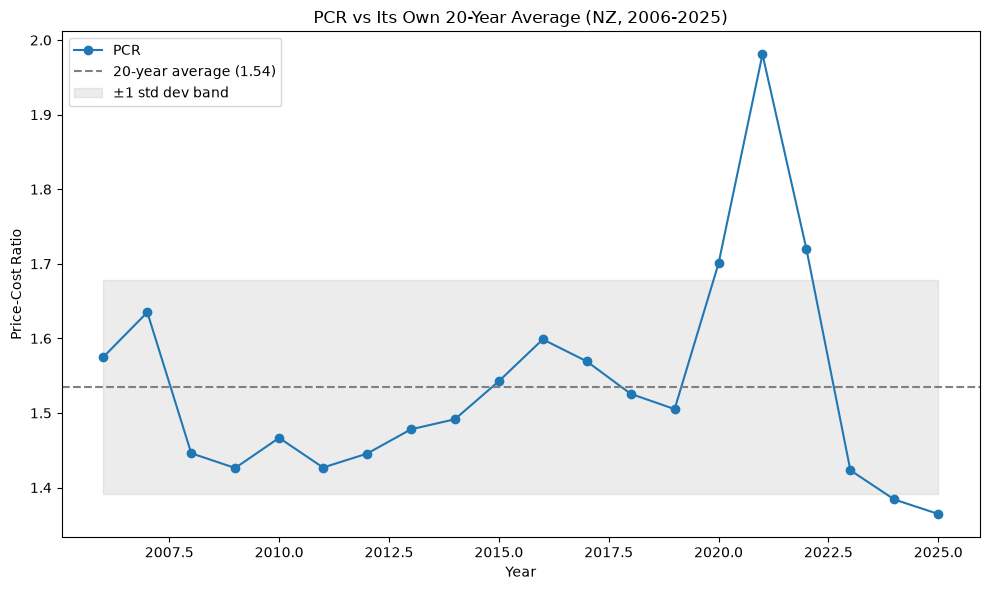

Current (2025) PCR: 1.365
20-year average PCR: 1.535 (std dev: 0.144)
Current PCR is -11.1% vs the 20-year average (z-score: -1.19)


In [20]:
pcr_mean = combined['pcr'].mean()
pcr_std = combined['pcr'].std()
current_pcr = combined.loc[combined['year'] == combined['year'].max(), 'pcr'].values[0]
pcr_zscore = (current_pcr - pcr_mean) / pcr_std
pcr_pct_vs_avg = (current_pcr / pcr_mean - 1) * 100

plt.figure(figsize=(10, 6))
plt.plot(combined['year'], combined['pcr'], marker='o', label='PCR')
plt.axhline(pcr_mean, color='gray', linestyle='--', label=f'20-year average ({pcr_mean:.2f})')
plt.fill_between(combined['year'], pcr_mean - pcr_std, pcr_mean + pcr_std, color='gray', alpha=0.15, label='±1 std dev band')
plt.xlabel('Year')
plt.ylabel('Price-Cost Ratio')
plt.title('PCR vs Its Own 20-Year Average (NZ, 2006-2025)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Current ({int(combined['year'].max())}) PCR: {current_pcr:.3f}")
print(f"20-year average PCR: {pcr_mean:.3f} (std dev: {pcr_std:.3f})")
print(f"Current PCR is {pcr_pct_vs_avg:+.1f}% vs the 20-year average (z-score: {pcr_zscore:+.2f})")


### 10b. Where are we in the cycle? Drawdown from the all-time high

A common way to frame timing in any asset market: how far is the current (real, inflation-adjusted) price below its all-time peak? `cummax()` tracks the running historical maximum, so the gap between it and the actual value at each point is the drawdown.

---

### 10b. 现在处在周期的什么位置？距离历史最高点的回撤

判断"现在算不算买入时机"的一个常见框架：当前(真实、剔除通胀后的)价格，比历史最高点低了多少？用 `cummax()` 追踪"截至目前为止出现过的最高值"，它跟每个时点实际值之间的差距就是回撤幅度。


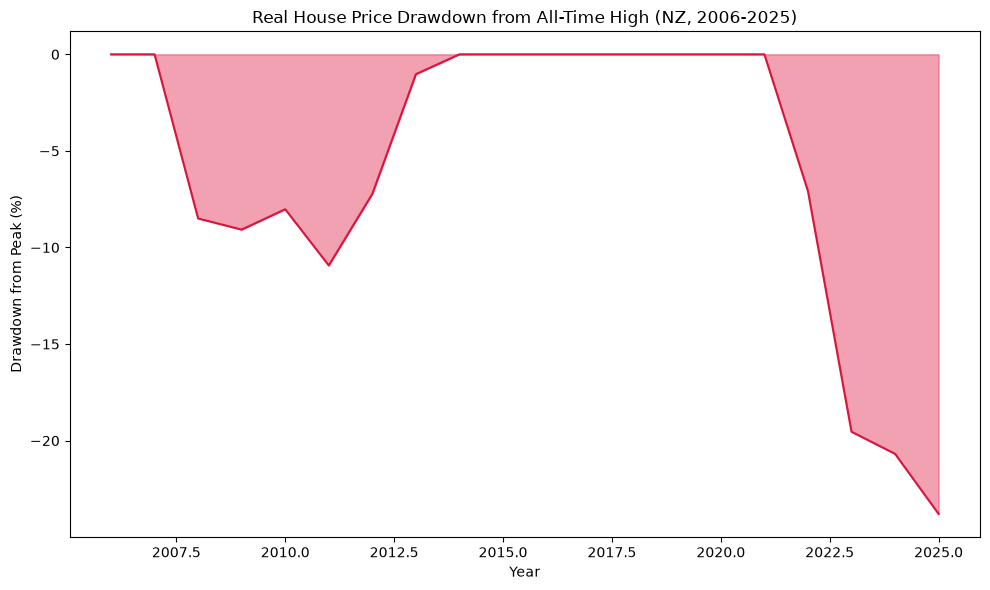

All-time real price peak: 2021 ($4512/m2, in 2006 dollars)
Current real price is -23.8% below that peak


In [21]:
combined['real_price_running_peak'] = combined['real_price_per_m2'].cummax()
combined['drawdown_from_peak_pct'] = (combined['real_price_per_m2'] / combined['real_price_running_peak'] - 1) * 100

peak_year = int(combined.loc[combined['real_price_per_m2'].idxmax(), 'year'])
peak_value = combined['real_price_per_m2'].max()
current_drawdown = combined['drawdown_from_peak_pct'].iloc[-1]

plt.figure(figsize=(10, 6))
plt.fill_between(combined['year'], combined['drawdown_from_peak_pct'], 0, color='crimson', alpha=0.4)
plt.plot(combined['year'], combined['drawdown_from_peak_pct'], color='crimson')
plt.xlabel('Year')
plt.ylabel('Drawdown from Peak (%)')
plt.title('Real House Price Drawdown from All-Time High (NZ, 2006-2025)')
plt.tight_layout()
plt.show()

print(f"All-time real price peak: {peak_year} (${peak_value:.0f}/m2, in {int(combined['year'].min())} dollars)")
print(f"Current real price is {current_drawdown:.1f}% {'below' if current_drawdown < 0 else 'above'} that peak")


### 10c. How risky is property as an asset class here?

Growth alone doesn't answer "is this a good investment" — the same return with less year-to-year volatility is a better risk-adjusted outcome. This measures the standard deviation of year-over-year nominal price growth.

---

### 10c. 房产作为一种资产，风险有多大？

只看涨幅回答不了"这是不是一项好投资"——同样的收益，年度波动更小的，风险调整后表现更好。这里用逐年名义房价涨幅的标准差衡量波动性。


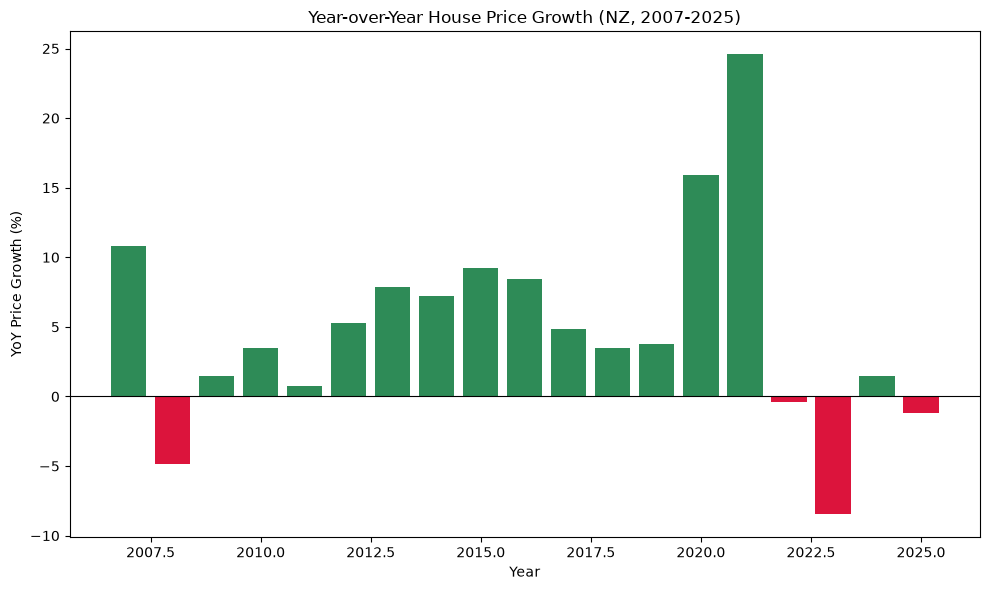

Average annual nominal price growth: 4.93%
Volatility (std dev of annual growth): 7.36 percentage points


In [22]:
combined['price_pct_change'] = combined['price_per_m2'].pct_change() * 100
price_volatility = combined['price_pct_change'].std()
avg_growth = combined['price_pct_change'].mean()

plt.figure(figsize=(10, 6))
colors = ['seagreen' if x >= 0 else 'crimson' for x in combined['price_pct_change'].fillna(0)]
plt.bar(combined['year'], combined['price_pct_change'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Year')
plt.ylabel('YoY Price Growth (%)')
plt.title('Year-over-Year House Price Growth (NZ, 2007-2025)')
plt.tight_layout()
plt.show()

print(f"Average annual nominal price growth: {avg_growth:.2f}%")
print(f"Volatility (std dev of annual growth): {price_volatility:.2f} percentage points")


### 10d. Where should capital go? Property vs term deposit vs cash, in real terms

Pulls together numbers already computed elsewhere into one apples-to-apples comparison: property's long-run **real** (inflation-adjusted) annualized return, a term deposit's **real** return at today's rate and inflation (nominal rate minus current inflation), and cash held idle (which loses value at the rate of inflation). Comparing a real return to a real return — not a real return to a nominal rate — is what makes this a fair comparison.

---

### 10d. 钱该往哪放？房产 vs 定存 vs 现金，按真实收益比

把前面已经算出来的数字整合成一次"同口径"对比：房产长期的**真实**(剔除通胀)年化收益率、按当前利率和当前通胀算出的定存**真实**收益率(名义利率减当前通胀)、闲置现金(随通胀贬值)。**拿真实收益率比真实收益率**，而不是拿真实收益率比名义利率，这才是公平的对比方式。


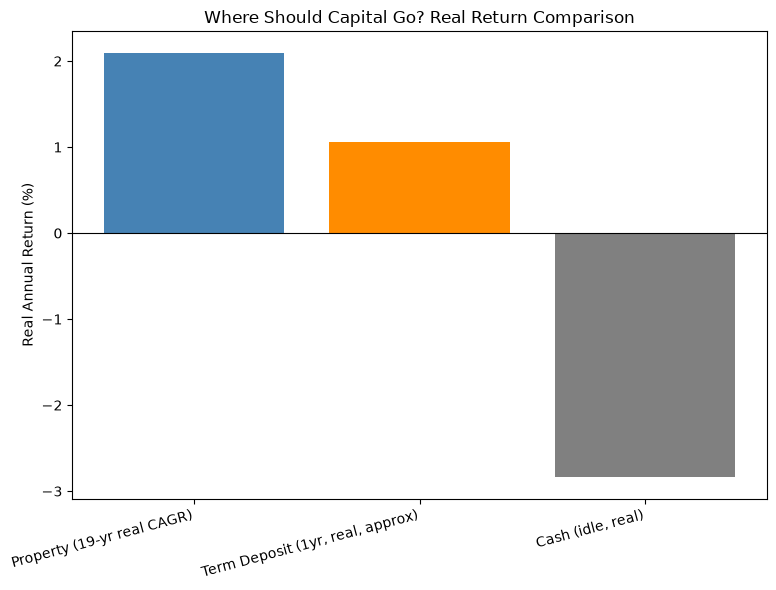

,Option,Real Annual Return (%)
0,Property (19-yr real CAGR),2.098513
1,"Term Deposit (1yr, real, approx)",1.060204
2,"Cash (idle, real)",-2.839796


In [23]:
years_span = int(combined['year'].max() - combined['year'].min())
real_price_start = combined['real_price_per_m2'].iloc[0]
real_price_end = combined['real_price_per_m2'].iloc[-1]
property_real_cagr = ((real_price_end / real_price_start) ** (1 / years_span) - 1) * 100

current_deposit_1yr = current_bank_rates.loc[current_bank_rates['term'] == '1 year', 'rate'].values[0]
current_inflation = combined['inflation_rate'].iloc[-1]
deposit_real_return = current_deposit_1yr - current_inflation

comparison = pd.DataFrame({
    'Option': [f'Property ({years_span}-yr real CAGR)', 'Term Deposit (1yr, real, approx)', 'Cash (idle, real)'],
    'Real Annual Return (%)': [property_real_cagr, deposit_real_return, -current_inflation]
})

plt.figure(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'gray']
plt.bar(comparison['Option'], comparison['Real Annual Return (%)'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Real Annual Return (%)')
plt.title('Where Should Capital Go? Real Return Comparison')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

comparison


**Interpretation — these four signals tell a consistent story:**

- **10a**: current PCR (1.365) sits 11.1% *below* its 20-year average (z-score -1.19) — property is currently priced *below* its typical historical premium over construction cost, not above it.
- **10b**: real prices are 23.8% below their 2021 peak — a substantial correction, not a recovery to new highs.
- **10c**: annual growth volatility (7.36 points) is actually *larger* than the average annual growth rate itself (4.93%) — year-to-year, this is a genuinely volatile asset, not a smooth one, even though the long-run trend is positive.
- **10d**: over the long run, property still wins on a real-return basis (2.10%/yr) versus a term deposit at today's rate (1.06%/yr real) and clearly beats holding cash (-2.84%/yr real) — but the margin over a term deposit is roughly 1 percentage point, not dramatic.

**Put together**: the popular narrative of "NZ housing is always expensive and always going up" is only partly supported by this data. Right now, by two independent measures (10a and 10b), property is priced *below* its recent historical norm, not above it — a genuinely different signal from what headlines usually suggest. At the same time, it is not a low-risk asset (10c), and its long-run real-return edge over a safe term deposit, while real, is modest rather than overwhelming (10d). None of this is a recommendation to buy or not buy — it's a set of measured, dated signals (as of 2025) that a buyer or investor can weigh alongside their own circumstances, which this analysis has no visibility into.

---

**解读——这四个信号指向一个相当一致的故事：**

- **10a**：当前 PCR(1.365)比自己20年均值**低**11.1%(z-score -1.19)——现在的房价相对建筑成本的溢价，是**低于**历史正常水平的，不是高于。
- **10b**：真实房价比2021年高点低23.8%——是一次实质性的回调，不是创新高。
- **10c**：年度涨幅的波动性(7.36个百分点)其实**比**平均年涨幅本身(4.93%)**还大**——逐年来看，这确实是一项波动挺大的资产，不是平稳的，尽管长期趋势是正的。
- **10d**：长期来看，房产在真实收益上依然领先(每年2.10%)，比按当前利率算的定存真实收益(每年1.06%)高，也明显跑赢闲置现金(每年-2.84%)——但领先定存的幅度大约只有1个百分点，不算悬殊。

**综合起来看**："NZ房产永远贵、永远涨"这种流行说法，只被这份数据部分支持。**现在**这个时间点，用两个独立指标(10a和10b)看，房价其实是**低于**近期历史正常水平的，不是高于——这跟新闻标题给人的印象不太一样。同时它也不是低风险资产(10c)，它相对安全的定存的长期真实收益优势虽然存在，但幅度温和，不算压倒性(10d)。这些都不构成"该不该买"的建议——只是一组截至(2025年)的量化信号，买家/投资者可以结合自己的具体情况去权衡，这些具体情况是这份分析看不到的。


## Deferred: Needs More Historical Data

`bank_rates`/`loan_rates`/`fx_rates` only have a handful of days of history (cron refreshes every 3 days, and it's only been running about a week). These are designed but not yet implementable:

- **Interest rate trend vs affordability**: how rate rises/falls have moved affordability over time, not just the current snapshot.
- **FX rate trend and volatility**: is NZD strengthening or weakening against major currencies, and how much currency risk does that represent for a foreign holder.
- **Foreign-currency-adjusted real house price**: combining the house price trend with the FX trend to show whether NZ property has gotten cheaper or more expensive for a foreign buyer over time, accounting for currency movement — the most sophisticated version of Analysis 9, but needs both datasets to have real depth first.

## Key Findings

1. **Unemployment's effect on affordability is specific, not general** — it significantly worsens deposit affordability (R²=0.51, p<0.001) but has no significant effect on mortgage or rent affordability. The barrier it raises is to *entering* home ownership, not to already-established housing costs.
2. **Property has genuinely outpaced inflation** — real (inflation-adjusted) price per m² rose ~48% from 2006-2025, with a clear COVID-era boom (2020-2021) and subsequent correction (2022-2023) visible in both nominal and real terms.
3. **GDP growth has a moderate link to the price-cost premium** (R²=0.259, p=0.022) — significant but weaker than the unemployment/deposit relationship; growth years coincide with houses selling for more relative to build cost, but ~74% of the variation is driven by other factors not modelled here.
4. **Paying down a mortgage currently beats a term deposit at every matching term** — the rate spread is positive (~0.8-1.2 points) across the board.
5. **A NZD ~$895k average house currently costs** roughly USD 523k / EUR 456k / CNY 3.53M / AUD 749k (see Analysis 9) at the latest FX snapshot — a reference point for foreign buyers, not a trend signal yet.
6. Not everything tested showed a relationship — `gdp_growth_rate` vs `price_per_m2` was essentially zero (r=0.01). Reporting a genuine null result honestly is part of the analysis, not a gap in it.
7. **GDP growth is the most robust driver of the price-cost premium** — in a joint model with unemployment and inflation, `gdp_growth_rate` stays significant (p=0.032) while `unemployment_rate`'s apparent effect largely washes out (p=0.070) and `inflation_rate` shows none at all (p=0.967). The two indicators were likely capturing overlapping signal in the single-variable version.
8. **Building consents do not clearly lead prices** — the same-year correlation with PCR (0.784) is stronger than the one-year-ahead correlation (0.616), the opposite of the "leading indicator" hypothesis. Consents look more coincident with current market conditions than predictive of future ones.
9. **Price level and affordability burden rank differently across cities** — Auckland is the most expensive city outright, but Wellington has the worst deposit affordability despite a lower price level, meaning its price growth has likely outpaced local income growth by more.

10. **Property is currently priced below its own historical norm, not above it** — the current price-cost ratio sits 11.1% below its 20-year average (z-score -1.19), and real prices are 23.8% below their 2021 peak. This runs counter to the "always overpriced" popular narrative.
11. **Property is not a low-risk asset year-to-year** — the volatility of annual price growth (7.36 points) exceeds the average annual growth rate itself (4.93%), even though the long-run trend is positive.
12. **Property beats a term deposit on real return, but not by a wide margin** — 2.10%/year real (19-year CAGR) vs 1.06%/year real for a term deposit at today's rate and inflation; both clearly beat holding idle cash (-2.84%/year real).

**Methodology notes carried through this analysis**: house-price metrics were deliberately kept to three non-redundant concepts (price level, activity, premium-over-cost) to avoid a correlation matrix cluttered with definitionally-related variables; the affordability index polarity was verified against the official HUD/data.govt.nz source rather than inferred from the raw numbers (an initial inference was wrong and had to be corrected); and every regression reports both R² and p-value together, since a strong-looking slope with a high p-value is not a finding.

---

## 待补充：需要更多历史数据积累

`bank_rates`/`loan_rates`/`fx_rates` 现在只有几天的历史(cron 每3天刷新一次，而且才跑了大概一周)。以下几项已经设计好，但现在还做不了：

- **利率趋势 vs 可负担性**：利率的升降如何随时间影响可负担性，不只是当前快照。
- **汇率趋势与波动性**：NZD 相对主要货币是在升值还是贬值，这对外国持有者意味着多大的汇率风险。
- **外币计价的真实房产成本变化**：把房价趋势和汇率趋势结合，看 NZD 计价之外、对外国买家来说这些年房产实际是变贵了还是变便宜了——是分析9的进阶版，但需要两边数据都有真正的历史深度。

## 关键发现

1. **失业率对可负担性的影响是特定的，不是普遍的**——显著恶化存首付可负担性(R²=0.51, p<0.001)，但对房贷月供、租金负担都没有显著影响。它抬高的是"进入"购房门槛的难度，不是已有住房成本的普遍恶化。
2. **房产确实跑赢了通胀**——剔除通胀后，每平米真实价格2006-2025涨了约48%，期间能清楚看到疫情期间的异常上涨(2020-2021)和随后的回调(2022-2023)。
3. **GDP增长率跟房价-成本溢价有中等强度的关系**(R²=0.259, p=0.022)——显著，但比失业率↔存首付那组弱；经济增长年份房价相对建筑成本确实卖得更贵，但约74%的波动由模型之外的其他因素决定。
4. **现在提前还房贷，在所有可比期限上都比存定期划算**——利差全部为正(约0.8-1.2个百分点)。
5. **一套约 NZD 895k 的均价房**，按最新汇率快照折算大约是 USD 523k / EUR 456k / CNY 353万 / AUD 749k(见分析9)——是给外国买家的参考点，还不是趋势信号。
6. 不是所有测试的关系都成立——`gdp_growth_rate` vs `price_per_m2` 基本没关系(r=0.01)。如实报告一个真实的"没发现"，也是分析的一部分，不是缺陷。
7. **GDP增长率是价格-成本溢价最稳健的驱动因素**——在跟失业率、通胀率一起建的联合模型里，`gdp_growth_rate` 依然显著(p=0.032)，`unemployment_rate` 看起来的效应基本消失(p=0.070)，`inflation_rate` 完全没有效应(p=0.967)。单变量版本里这两个指标很可能捕捉到的是重叠的信号。
8. **建筑许可数量没有清楚地"领先"于房价**——跟PCR的同期相关性(0.784)比领先一年的相关性(0.616)更强，跟"领先指标"假设正好相反。许可数量看起来更像是跟当前市场状况同步，而不是预测未来。
9. **价格水平排名和可负担性负担排名不一致**——奥克兰绝对价格最贵，但惠灵顿的存首付可负担性最差，尽管惠灵顿价格水平更低，说明它的房价涨幅很可能比当地收入涨幅拉开得更大。

10. **当前房价相对自己的历史正常水平是偏低的，不是偏高**——当前价格-成本比比20年均值低11.1%(z-score -1.19)，真实房价比2021年高点低23.8%。这跟"永远高估"的流行说法相反。
11. **房产逐年来看不是低风险资产**——年涨幅的波动性(7.36个百分点)超过了平均年涨幅本身(4.93%)，尽管长期趋势是正的。
12. **房产的真实收益跑赢定存，但幅度不大**——19年真实年化收益2.10% vs 按当前利率算的定存真实收益1.06%；两者都明显跑赢闲置现金(真实收益-2.84%/年)。

**贯穿这次分析的方法论要点**：房价指标特意精简成三个互不重复的概念(价格水平、活跃度、相对成本的溢价)，避免相关系数矩阵里塞满定义上就相关的变量；可负担性指数的方向核实自 HUD/data.govt.nz 官方数据源说明，不是从数字趋势猜的(第一次的推测是错的，后来纠正过)；每次回归都同时报告 R² 和 p-value，因为看起来很陡的斜率如果 p-value 很高，也不算一个发现。
